# Week 1 Lab: Probability, sampling and a first look at an LLM

**Module:** Generative AI (MSc in Artificial Intelligence) · **Time:** 2 hours · **Learning outcomes:** MIMLO 1, MIMLO 4

In this lab you will:

1. build a tiny **generative model** of names from counts, measure its **likelihood** and sample from it at different **temperatures**;
2. compare a **generative** and a **discriminative** classifier on the same data, and generate new data from the generative one;
3. run a small **open-weight language model**, look inside its next-token probabilities and change the decoding settings;
4. probe **hallucination** and compare a small open model with a large hosted assistant;
5. record your evidence and apply the five-step responsible-use checklist.

| Part | Topic | Suggested time |
|---|---|---|
| 0 | Setup | 10 min |
| 1 | A generative model from counts | 35 min |
| 2 | Generative vs. discriminative | 20 min |
| 3 | A small LLM in action | 35 min |
| 4 | Hallucination and tool comparison | 15 min |
| 5 | Evidence and reflection | 5 min |

> **How to run this notebook**
> - **Google Colab (recommended):** File ▸ Upload notebook, then Runtime ▸ Change runtime type ▸ **T4 GPU**. Run cells top to bottom with Shift+Enter.
> - **Local Jupyter / VS Code:** Python 3.10+; run the install cell once. A GPU is optional: every cell has a CPU-friendly setting.
> - **API keys (optional cells only):** store keys in Colab ▸ 🔑 Secrets or an environment variable. Never paste a key into a notebook you share.
> - Cells marked **TODO** are yours to complete. Questions marked ✍️ need a short written answer.

## Before coding: follow the complete flow

A **model** describes possible outputs. **Training** builds that description;
**sampling** uses it to draw an output. This lab starts with a table you can
inspect, then applies the same probability ideas to a neural language model.

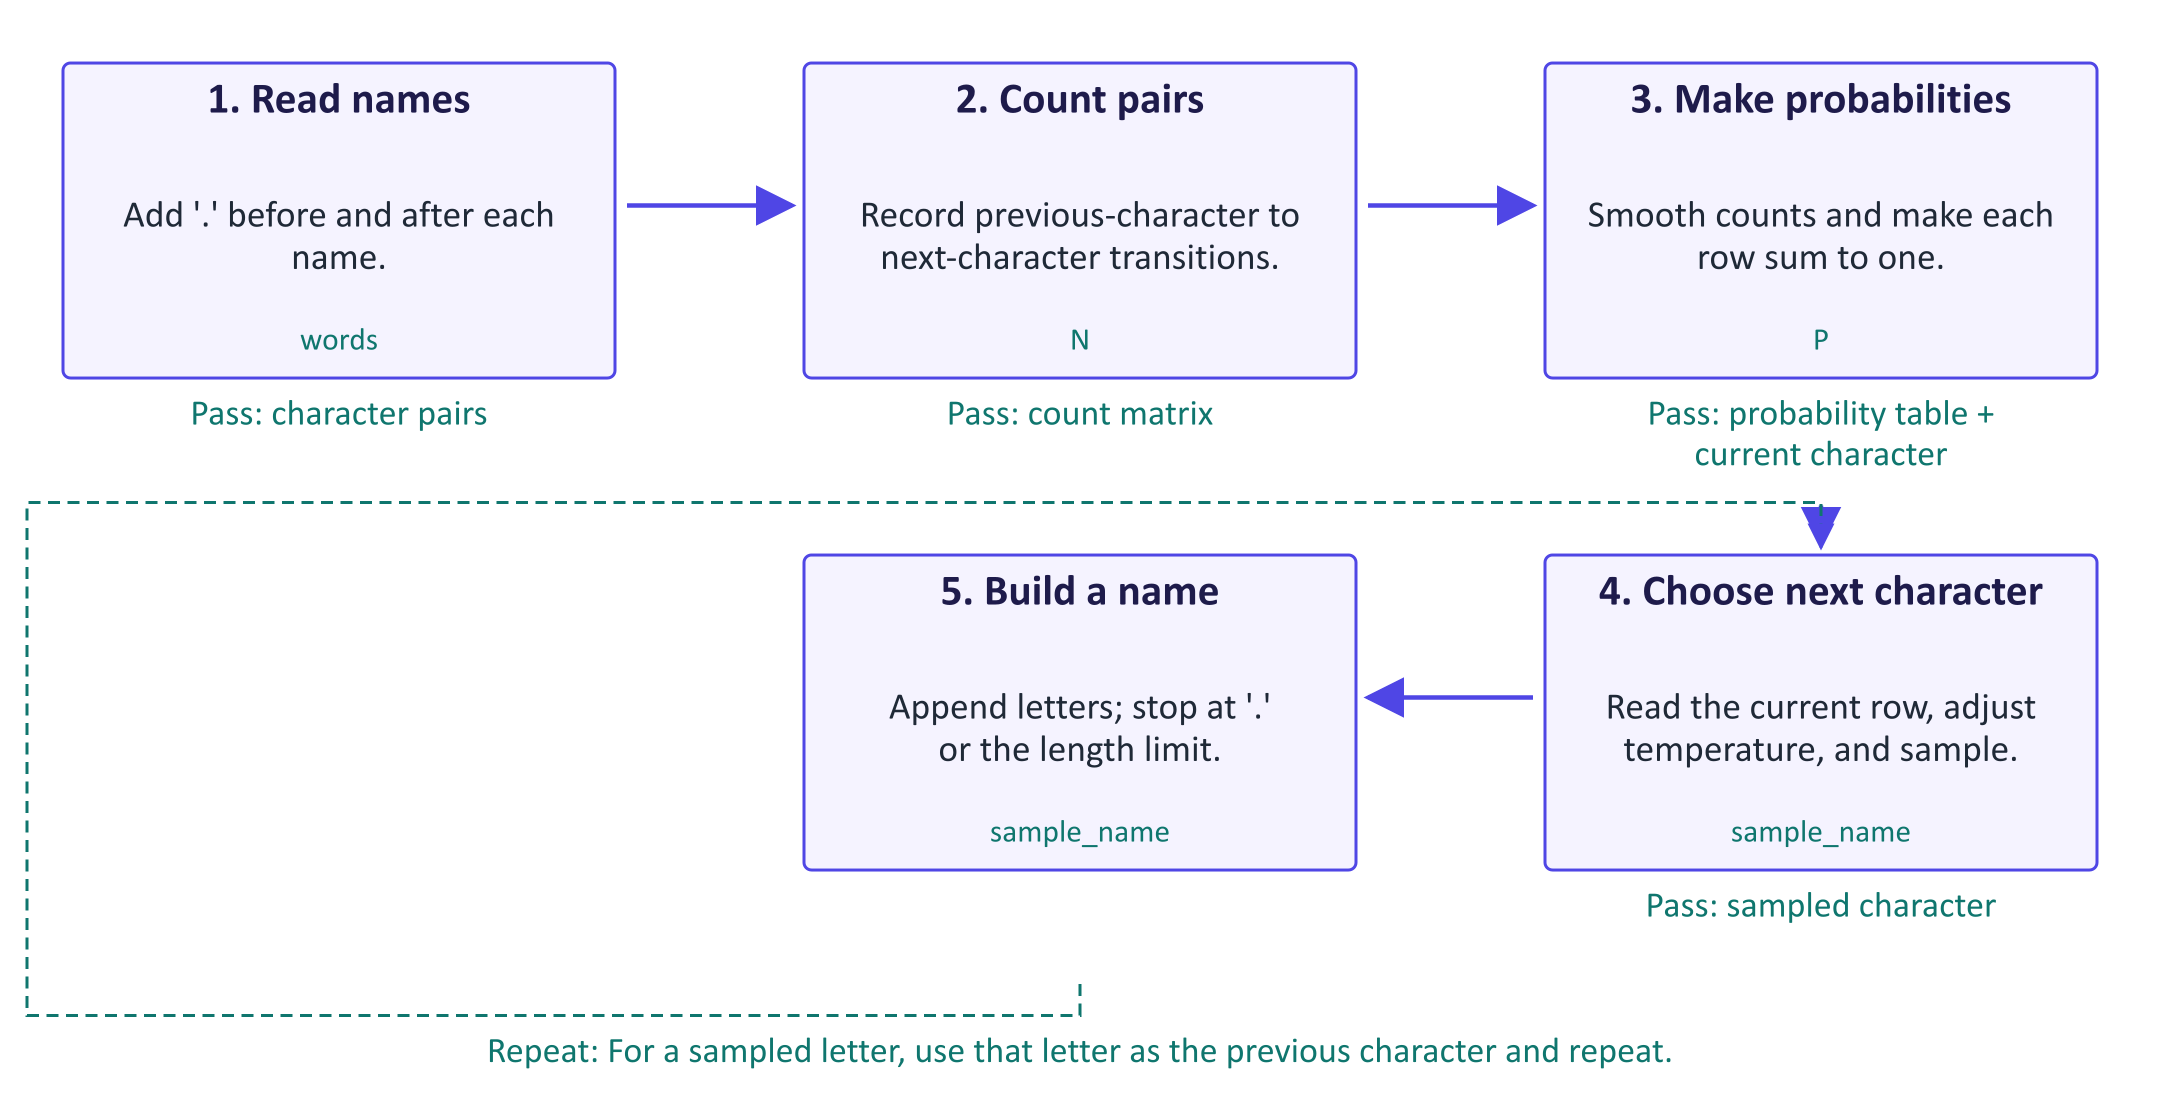

Read the blocks left to right: `words` supplies names; `N` stores adjacent
character counts; `P` stores next-character probabilities; `sample_name`
repeatedly chooses a character. The sampled character selects the next row.
`avg_nll` scores a supplied name instead of generating one.

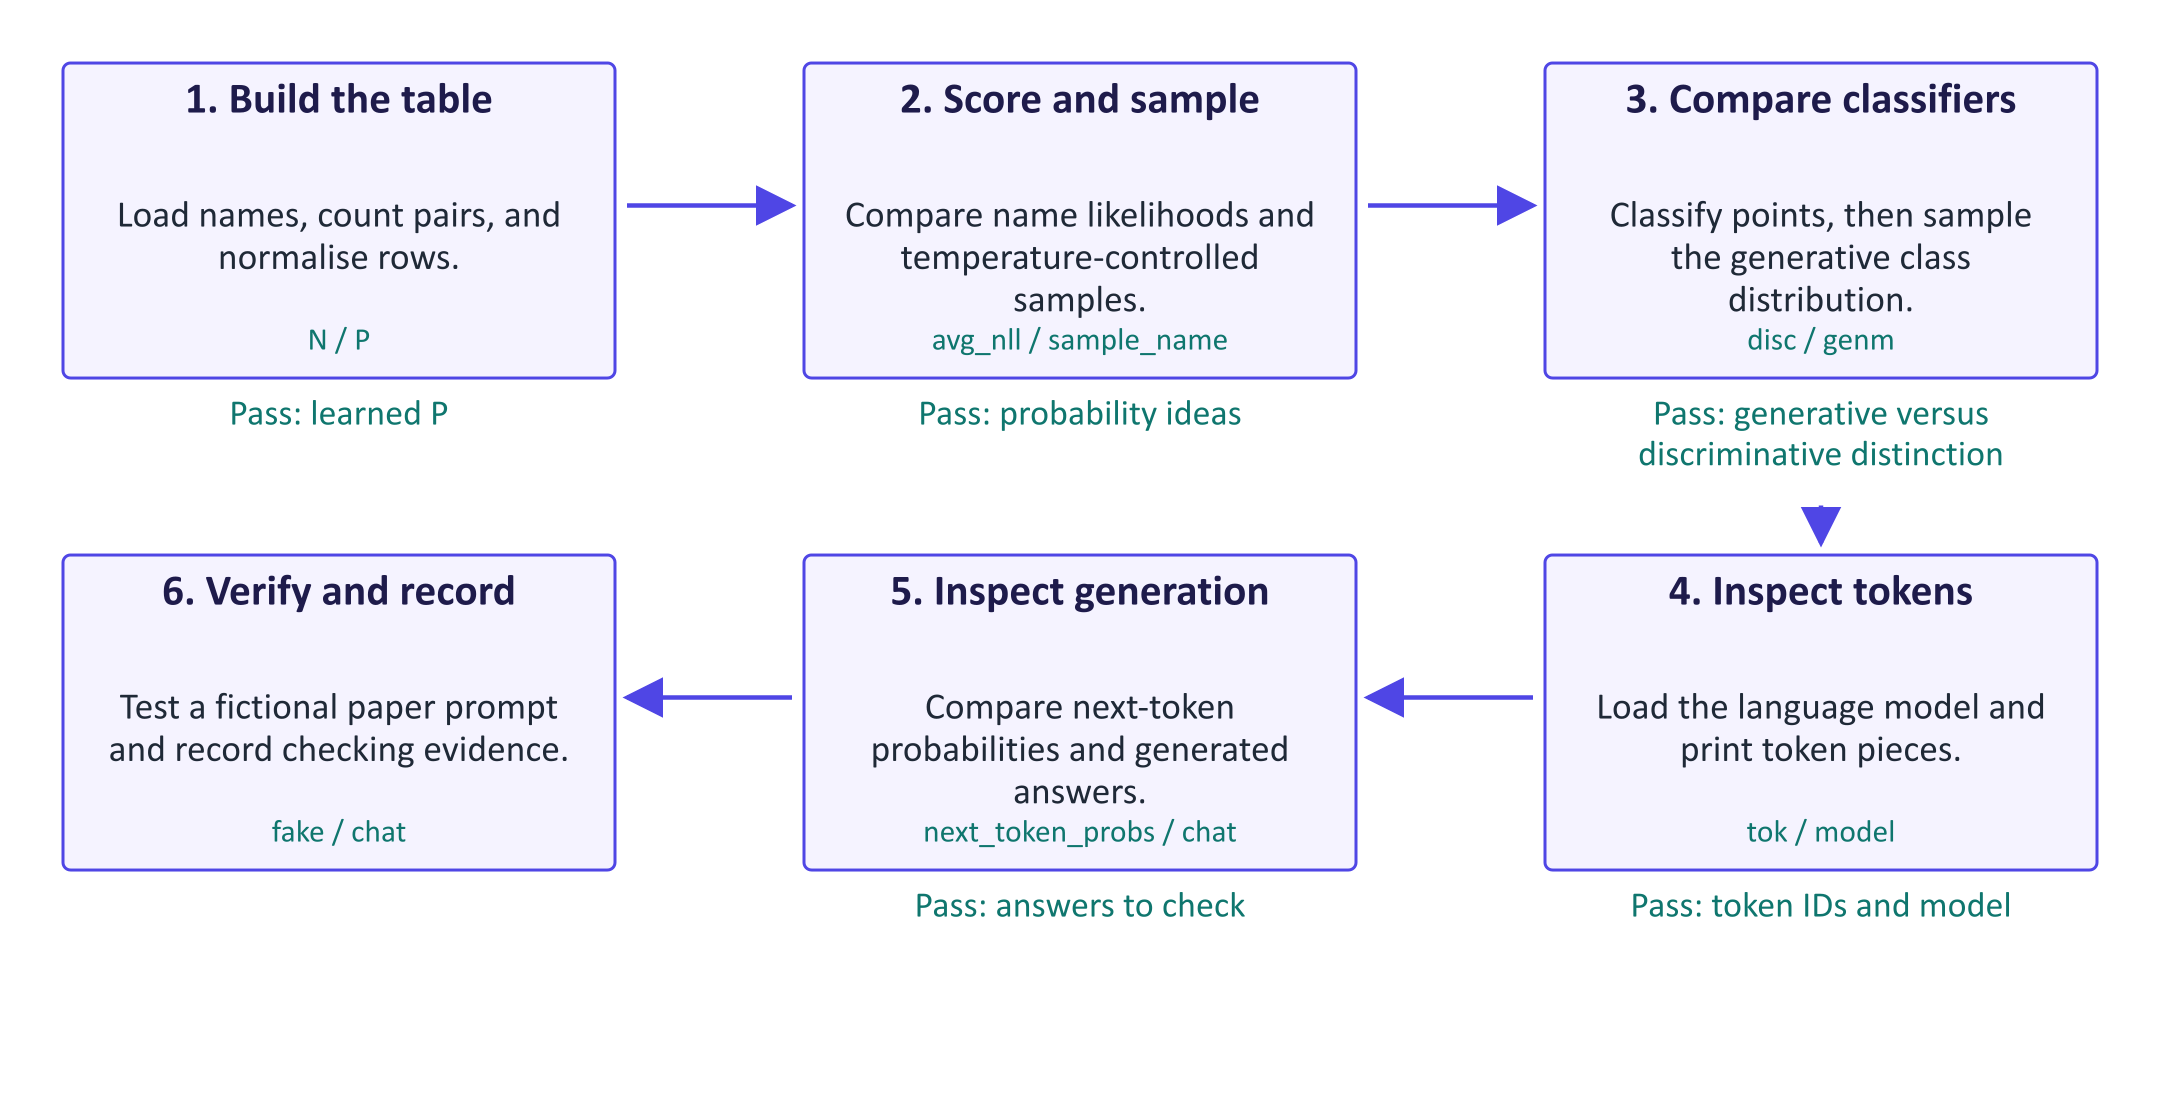

| Diagram block | Code to find | First observation |
|---|---|---|
| Build the table | `N`, `P` | Matrix rows mean previous characters; each probability row sums to 1. |
| Score and sample | `avg_nll`, `sample_name` | Scoring receives a name; generation creates one. |
| Compare classifiers | `disc`, `genm` | QDA learns an input distribution that can be sampled. |
| Inspect tokens | `tok`, `model` | Token pieces and integer IDs describe the same input. |
| Inspect generation | `next_token_probs`, `chat` | A next-token distribution differs from a complete answer. |
| Verify and record | `fake`, the evidence table | Record observed claims and how you checked them. |

**Pause and predict:** after generating `e`, which probability row should be
read next? Point to the block that repeats before running the sampler.
Work through the TODOs yourself; the diagrams describe roles and data flow.

## Part 0 · Setup

Run the next cell once. On Google Colab most packages are already installed, so it finishes quickly.

In [ ]:
%pip install -q transformers accelerate scikit-learn matplotlib

In [ ]:
import math
import os
import random
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import torch

# SMOKE mode is only used by the instructor's automatic test: tiny settings so every cell runs quickly.
SMOKE = os.environ.get("GENAI_LAB_SMOKE") == "1"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| device:", DEVICE)
if DEVICE == "cpu":
    print("No GPU found. That is fine for this lab; the language model part will just be a little slower.")

## Part 1 · A generative model from counts

We model names **one character at a time**. A *bigram* model assumes each character depends only on the previous one:

$$p(\text{name}) = \prod_{t} p(c_t \mid c_{t-1})$$

The special token `.` marks the start and end of a name, so `emma` is modelled as `. e m m a .`

### 1.1 Load the data

In [ ]:
URL = "https://raw.githubusercontent.com/karpathy/makemore/master/names.txt"
FALLBACK = """emma olivia ava isabella sophia charlotte mia amelia harper evelyn abigail emily elizabeth
mila ella avery sofia camila aria scarlett victoria madison luna grace chloe penelope layla riley
zoey nora lily eleanor hannah lillian addison aubrey ellie stella natalie zoe leah hazel violet
aurora savannah audrey brooklyn bella claire skylar lucy paisley everly anna caroline nova genesis
liam noah william james oliver benjamin elijah lucas mason logan alexander ethan jacob michael
daniel henry jackson sebastian aiden matthew samuel david joseph carter owen wyatt john jack luke
jayden dylan grayson levi isaac gabriel julian mateo anthony jaxon lincoln joshua christopher""".split()

try:
    with urllib.request.urlopen(URL, timeout=15) as f:
        words = f.read().decode("utf-8").split()
    print("Downloaded", len(words), "names")
except Exception as e:
    words = FALLBACK
    print("Download failed, using the built-in list of", len(words), "names:", e)

if SMOKE:
    words = words[:2000]
print(words[:10])

### 1.2 Count bigrams

Build the vocabulary (26 letters plus `.`), then count how often each character follows each other character.

**TODO 1:** fill the count matrix `N`, where `N[i, j]` is the number of times character `j` follows character `i`.

**Read the shapes:** `N` has `V` rows and `V` columns. `stoi` translates a
character to its index; `itos` translates an index back to a character.
Adding start and end markers makes both beginning and stopping learnable.

In [ ]:
chars = sorted(set("".join(words)))
stoi = {c: i + 1 for i, c in enumerate(chars)}
stoi["."] = 0
itos = {i: c for c, i in stoi.items()}
V = len(stoi)
print("vocabulary size:", V)

N = np.zeros((V, V), dtype=np.int64)
for w in words:
    seq = ["."] + list(w) + ["."]
    for a, b in zip(seq, seq[1:]):
        pass  # TODO: write your code here

print("total bigrams counted:", N.sum())
print("most common first letters:", [itos[j] for j in np.argsort(-N[0])[:5]])

In [ ]:
plt.figure(figsize=(7, 6))
plt.imshow(np.log1p(N), cmap="Purples")
plt.xticks(range(V), [itos[i] for i in range(V)])
plt.yticks(range(V), [itos[i] for i in range(V)])
plt.xlabel("next character")
plt.ylabel("previous character")
plt.title("log(1 + bigram count)")
plt.show()

### 1.3 From counts to probabilities (maximum likelihood)

The maximum-likelihood estimate of $p(c_t = j \mid c_{t-1} = i)$ is simply the fraction of times `j` follows `i`.
We add 1 to every count (**add-one smoothing**) so that no bigram gets probability exactly zero.
This is a smoothed estimate: without the added counts, row normalisation is
the ordinary maximum-likelihood estimate. `axis=1` totals each row, and
`keepdims=True` keeps a column shape so division applies to every row entry.

In [ ]:
P = (N + 1) / (N + 1).sum(axis=1, keepdims=True)
print("each row sums to 1:", np.allclose(P.sum(axis=1), 1.0))
print("p(next | '.') for a, e, z:", round(P[0, stoi["a"]], 3), round(P[0, stoi["e"]], 3), round(P[0, stoi["z"]], 3))

**TODO 2:** write `avg_nll(word, P)`, the **average negative log-likelihood per character** of a word, including the final `.`.
For `emma` you average over five predictions: `.→e, e→m, m→m, m→a, a→.`

In [ ]:
def avg_nll(word, P):
    # Read-only scoring: this function does not update the learned table P.
    seq = ["."] + list(word) + ["."]
    pass  # TODO: write your code here


for w in ["emma", "anna", "xqzz"]:
    print(f"{w:6s} average NLL = {avg_nll(w, P):.3f} nats  (perplexity {math.exp(avg_nll(w, P)):.1f})")

Now compare three models on the whole dataset. Lower negative log-likelihood means the model finds real names more probable.

* **uniform**: every next character equally likely, $-\log(1/27)$
* **unigram**: next character ignores the previous one
* **bigram**: our model

In [ ]:
uni = (N.sum(axis=0) + 1) / (N.sum() + V)
P_uni = np.tile(uni, (V, 1))
total = {"uniform": [], "unigram": [], "bigram": []}
for w in words:
    total["uniform"].append(math.log(V))
    total["unigram"].append(avg_nll(w, P_uni))
    total["bigram"].append(avg_nll(w, P))
for k, v in total.items():
    print(f"{k:8s}: {np.mean(v):.3f} nats per character")

### 1.4 Sampling with temperature

**TODO 3:** complete `sample_name`. Starting from `.`, repeatedly
1. take the row of probabilities for the current character,
2. apply temperature: $p_i \propto p_i^{1/T}$ (this is the same as dividing log-probabilities by $T$ before the softmax),
3. sample the next character, stop when you sample `.`.

In [ ]:
rng = np.random.default_rng(SEED)


def sample_name(P, T=1.0, max_len=20):
    # i is the previous character's index; index 0 represents the '.' marker.
    out, i = [], 0
    for _ in range(max_len):
        pass  # TODO: write your code here
        if i == 0:
            break
        out.append(itos[i])
    return "".join(out)


for T in [0.5, 1.0, 1.5]:
    print(f"T={T}:", ", ".join(sample_name(P, T) for _ in range(10)))

✍️ **Question 1.** Describe how the names change as the temperature goes from 0.5 to 1.5. Link your answer to what temperature does to the distribution.

*✍️ Write your answer here.*

## Part 2 · Generative vs. discriminative

We fit two classifiers to the same 2-D data:

* **Logistic regression** models $p(y \mid x)$ directly (discriminative).
* **Quadratic discriminant analysis (QDA)** fits a Gaussian $p(x \mid y)$ for each class plus $p(y)$, then classifies with Bayes' rule (generative).

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

gen = np.random.default_rng(1)
Xa = gen.multivariate_normal([-1.2, 0.3], [[0.6, 0.25], [0.25, 0.4]], 300)
Xb = gen.multivariate_normal([1.1, -0.2], [[0.5, -0.2], [-0.2, 0.6]], 300)
X = np.vstack([Xa, Xb])
y = np.array([0] * 300 + [1] * 300)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)

disc = LogisticRegression().fit(Xtr, ytr)
genm = QuadraticDiscriminantAnalysis(store_covariance=True).fit(Xtr, ytr)
print(f"logistic regression test accuracy: {disc.score(Xte, yte):.3f}")
print(f"QDA (generative) test accuracy:     {genm.score(Xte, yte):.3f}")

**TODO 4:** use the fitted generative model to **create 200 new points of class 0**. QDA stores the class means in `genm.means_` and the covariance matrices in `genm.covariance_`.

In [ ]:
new_points = np.zeros((200, 2))  # replace with samples from the class-0 Gaussian

plt.figure(figsize=(6, 5))
plt.scatter(*Xa.T, s=8, alpha=0.4, label="real class 0")
plt.scatter(*Xb.T, s=8, alpha=0.4, label="real class 1")
plt.scatter(*new_points.T, s=14, marker="*", color="black", label="generated class 0")
plt.legend()
plt.title("A generative classifier can also generate")
plt.show()

✍️ **Question 2.** Both classifiers have similar accuracy. Why can only one of them generate new data? When would you still prefer the discriminative model?

*✍️ Write your answer here.*

## Part 3 · A small open LLM in action

We load **SmolLM2**, a small open-weight model from Hugging Face. It is tiny compared with frontier assistants, which makes its behaviour (and its mistakes) easy to study. It runs on a CPU; a GPU makes it faster.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "HuggingFaceTB/SmolLM2-135M-Instruct" if SMOKE else "HuggingFaceTB/SmolLM2-360M-Instruct"
tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE)
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f"{MODEL_ID}: {n_params / 1e6:.0f} million parameters, vocabulary of {tok.vocab_size} tokens")

### 3.1 Tokens
How does the tokenizer split text? Compare an English sentence with the same sentence in another language.

In [ ]:
sentences = {
    "English": "Generative models learn a probability distribution over data.",
    "Irish": "Foghlaimíonn samhlacha giniúnacha dáileadh dóchúlachta thar shonraí.",
    "Hindi": "जनरेटिव मॉडल डेटा पर प्रायिकता वितरण सीखते हैं।",
}
for lang, s in sentences.items():
    ids = tok(s)["input_ids"]
    pieces = tok.convert_ids_to_tokens(ids)
    print(f"{lang:8s} {len(ids):3d} tokens | {pieces[:12]}")

### 3.2 Inside the model: next-token probabilities
The model outputs a **logit** for every token in its vocabulary. Softmax turns logits into probabilities.

**TODO 5:** complete `next_token_probs` so it applies a temperature `T` to the logits before the softmax.

**Read the output:** model logits have batch, sequence-position, and
vocabulary dimensions. Selecting `[0, -1]` asks about the next token after
this single prompt, leaving one score per vocabulary item. This function
inspects one prediction; `chat` below performs the repeated generation loop.

In [ ]:
@torch.no_grad()
def next_token_probs(prompt, T=1.0):
    ids = tok(prompt, return_tensors="pt").to(DEVICE)
    logits = model(**ids).logits[0, -1]  # logits for the next position
    pass  # TODO: write your code here


prompt = "The cat sat on the"
for T in [0.5, 1.0, 1.5]:
    probs = next_token_probs(prompt, T)
    top = torch.topk(probs, 5)
    row = ", ".join(f"{tok.decode([int(i)])!r}: {p:.2f}" for p, i in zip(top.values.tolist(), top.indices.tolist()))
    print(f"T={T}: {row}")

### 3.3 Decoding settings change the output, not the model
We ask the same question several times with a low and a high temperature.

In [ ]:
def chat(question, temperature=0.7, top_p=0.9, max_new_tokens=60, system=None):
    # The chat template adds role markers; generated output also contains the input.
    # Decoding slices off those input tokens so the returned text is only the answer.
    messages = ([{"role": "system", "content": system}] if system else []) + [{"role": "user", "content": question}]
    inputs = tok.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt", return_dict=True).to(DEVICE)
    out = model.generate(**inputs, max_new_tokens=16 if SMOKE else max_new_tokens, do_sample=temperature > 0,
                         temperature=temperature if temperature > 0 else None, top_p=top_p if temperature > 0 else None,
                         pad_token_id=tok.eos_token_id)
    return tok.decode(out[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()


q = "Give a one-sentence definition of generative AI."
for T in [0.2, 1.2]:
    print(f"--- temperature {T}")
    for k in range(2 if SMOKE else 3):
        print(f"[{k + 1}]", chat(q, temperature=T))

## Part 4 · Hallucination and tool comparison

The paper below **does not exist**. Watch what a small model does when asked about it, then see whether an instruction to admit uncertainty helps.

In [ ]:
fake = "Summarise the main findings of the 2019 paper 'Quantum Gradient Folding for Transformers' by Smith and Okafor."
print("Plain question:\n", chat(fake, temperature=0.7, max_new_tokens=90))
print("\nWith an honesty instruction:\n", chat(fake, temperature=0.7, max_new_tokens=90,
      system="If you are not certain that a paper exists, say so clearly instead of guessing."))

### Optional: compare with a large hosted model (free Gemini API key)

1. Create a free key at **Google AI Studio** (aistudio.google.com) with your own account.
2. In Colab, open 🔑 **Secrets**, add `GEMINI_API_KEY`, and allow this notebook to use it.
3. Run the cell. Without a key it simply skips; you can paste the same prompt into any chat assistant instead.

In [ ]:
def get_key(name="GEMINI_API_KEY"):
    try:
        from google.colab import userdata  # only available on Colab
        return userdata.get(name)
    except Exception:
        return os.environ.get(name)


key = None if SMOKE else get_key()
if not key:
    print("No GEMINI_API_KEY found: skipping the hosted-model comparison. Use a chat assistant in your browser instead.")
else:
    try:
        from google import genai
    except ImportError:
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "google-genai"])
        from google import genai
    client = genai.Client(api_key=key)
    resp = client.models.generate_content(model="gemini-flash-latest", contents=fake)
    print(resp.text)

✍️ **Question 3.** What did the small model do with the fake paper? Did the honesty instruction help? How did the large hosted model (or a chat assistant) behave? Which step of the five-step checklist catches this problem?

*✍️ Write your answer here.*

## Part 5 · Evidence table and reflection

Complete the table with **two** of your experiments (double-click to edit).

| Task | Model and version | Settings (T, top-p, seed) | What happened | Correct? How did you check? | One improvement |
|---|---|---|---|---|---|
| | | | | | |
| | | | | | |

✍️ **Question 4.** Apply the five-step checklist (purpose, protect data, prompt clearly, verify, disclose) to one way you plan to use AI tools in this module.

*✍️ Write your answer here.*

**Before next week:** watch the 3Blue1Brown video *Large Language Models explained briefly* and read Foster (2023), chapter 1.